# Capacidad predictiva de índices PCA en datos taxonómicos

## Objetivo

Comparar los índices de Hotelling $T^2$, estadístico $Q$ e índice combinado
para distinguir muestras rurales y urbanas usando dos tratamientos:

1. **Sin tratamiento composicional:** transformación no lineal usada en el
   análisis original y estandarización.
2. **Con tratamiento composicional:** transformación CLR dentro de cada fold y
   estandarización.

La selección de características, el ajuste del escalador y el PCA se realizan
sólo con el conjunto de entrenamiento de cada fold.

### Reproducción histórica y alineación

`LEGACY_POSITIONAL_ALIGNMENT = True` reproduce los resultados de la libreta
original. En ese análisis, la tabla sin tratamiento (205 muestras) se divide
con las posiciones de la tabla tratada (199 muestras). Para una comparación
por los mismos individuos, cambia el parámetro a `False`; entonces ambas tablas
se alinean explícitamente por `SampleID`.


## 1. Configuración y carga de datos


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2, kstest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from src.microbiome_analysis.compositional import clr_transform

DATA_ROOT = PROJECT_ROOT / "data"
DATASETS = DATA_ROOT / "processed"
EXTERNAL_DATA = DATA_ROOT / "external"
TAXONOMIC_TABLES = PROJECT_ROOT / "results" / "tables" / "02_clr_pca_exploration"
OUTPUT = PROJECT_ROOT / "results" / "tables" / "07_taxonomic_indices_predictive_comparison"
FIGURES = PROJECT_ROOT / "results" / "figures" / "07_taxonomic_indices_predictive_comparison"
OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

LEGACY_POSITIONAL_ALIGNMENT = True
RANDOM_STATE = 42
N_SPLITS = 5
KS_P_VALUE = 0.001
PCA_VARIANCE = 0.90
ALPHA = 0.05

treated_abundance = pd.read_csv(
    TAXONOMIC_TABLES / "taxonomic_genus_clr_pseudocount_150.csv", index_col=0
)
untreated_abundance = pd.read_csv(TAXONOMIC_TABLES / "taxonomic_genus_relative_abundance.csv", index_col=0)
metadata = pd.read_csv(DATASETS / "latinbiota_sample_metadata.csv")
metadata = metadata.set_index("Lane", drop=False)

# El análisis original elimina cualquier fila tratada cuya suma sea cero.
treated_abundance = treated_abundance.loc[treated_abundance.sum(axis=1) > 0]
labels = metadata.loc[treated_abundance.index, "Lifestyle"]

if LEGACY_POSITIONAL_ALIGNMENT:
    untreated_for_cv = untreated_abundance.iloc[:len(treated_abundance)].copy()
else:
    untreated_for_cv = untreated_abundance.loc[treated_abundance.index].copy()

print("Tratada:", treated_abundance.shape)
print("Sin tratamiento:", untreated_abundance.shape)
print("Coincidencias por posición:", sum(treated_abundance.index == untreated_for_cv.index), "de", len(treated_abundance))
labels.value_counts()


Tratada: (199, 200)
Sin tratamiento: (205, 1262)
Coincidencias por posición: 10 de 199


Lifestyle
Rural    117
Urban     82
Name: count, dtype: int64

## 2. Métricas y selección de características

El test KS reproduce la dirección y el umbral del código original. Para el
modelo CLR se combinan características asociadas a ambos grupos; para el modelo
sin tratamiento se conservan las características asociadas al grupo urbano,
igual que en la implementación histórica.


In [2]:
def binary_metrics(y_true, y_pred, pos_label="Urban"):
    # Calcula las métricas binarias usadas en la libreta original.
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=["Rural", "Urban"]
    ).ravel()
    return {
        "F1": f1_score(y_true, y_pred, pos_label=pos_label),
        "Precision": precision_score(y_true, y_pred, pos_label=pos_label),
        "Recall": recall_score(y_true, y_pred, pos_label=pos_label),
        "Specificity": tn / (tn + fp),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    }


def select_features_by_ks(feature_table, rural_ids, urban_ids,
                          method="exact", p_value=0.001):
    # feature_table tiene características en filas y muestras en columnas.
    rural_columns = [sample for sample in rural_ids if sample in feature_table.columns]
    urban_columns = [sample for sample in urban_ids if sample in feature_table.columns]
    rural_values = feature_table[rural_columns].T
    urban_values = feature_table[urban_columns].T

    rural_features, urban_features = [], []
    for feature in feature_table.index:
        if kstest(rural_values[feature], urban_values[feature],
                  alternative="less", method=method).pvalue <= p_value:
            rural_features.append(feature)
        if kstest(urban_values[feature], rural_values[feature],
                  alternative="less", method=method).pvalue <= p_value:
            urban_features.append(feature)
    return rural_features, urban_features


## 3. Transformaciones de entrada

La función `custom_transform` pertenece a la ruta sin tratamiento
composicional. La ruta composicional utiliza CLR con el pseudoconteo `1e-6`,
exactamente como la libreta original.


In [3]:
def custom_transform(value):
    # Transformación histórica para abundancias sin tratamiento composicional.
    if value <= 1:
        return np.log2(2 * value + 0.00001)
    return np.sqrt(value)


def make_feature_matrix(feature_table, sample_ids, features, nonlinear=False):
    # Construye muestras × características y crea ceros para rasgos ausentes.
    ordered_features = list(dict.fromkeys(features))
    available_samples = [sample for sample in sample_ids if sample in feature_table.columns]
    matrix = pd.DataFrame(index=available_samples)
    for feature in ordered_features:
        if feature in feature_table.index:
            matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
        else:
            matrix[feature] = 0.0
    if nonlinear:
        matrix = matrix.apply(lambda column: column.map(custom_transform))
    return matrix


## 4. Modelo de índices PCA

Se conserva la definición histórica de los umbrales $T^2$, $Q$ y combinado.
En particular, el cuantil de $Q$ usa `chi2.ppf(alpha, ...)`, porque cambiarlo
alteraría los resultados que se desean reproducir.


In [4]:
def calculate_pca_parameters(training_matrix, variance=0.90, alpha=0.05):
    pca = PCA().fit(training_matrix)
    eigenvalues = pca.explained_variance_
    cumulative = np.cumsum(eigenvalues / eigenvalues.sum())

    principal_mask = cumulative < variance
    residual_mask = ~principal_mask
    principal_components = pca.components_[principal_mask]
    principal_values = eigenvalues[principal_mask]
    residual_components = pca.components_[residual_mask]
    residual_values = eigenvalues[residual_mask]

    D = principal_components.T @ np.linalg.inv(np.diag(principal_values)) @ principal_components
    t2_threshold = chi2.ppf(1 - alpha, len(principal_components))

    C = residual_components.T @ residual_components
    theta1 = residual_values.sum()
    theta2 = np.square(residual_values).sum()
    q_threshold = (
        (theta2 / theta1)
        * chi2.ppf(alpha, len(residual_components))
        * ((theta1 ** 2) / theta2)
    )

    combined_matrix = D / t2_threshold + C / q_threshold
    g = (
        (len(principal_components) / t2_threshold**2 + theta2 / q_threshold**2)
        / (len(principal_components) / t2_threshold + theta1 / q_threshold)
    )
    h = (
        (len(principal_components) / t2_threshold + theta1 / q_threshold) ** 2
        / (len(principal_components) / t2_threshold**2 + theta2 / q_threshold**2)
    )
    combined_threshold = g * chi2.ppf(1 - alpha, h)
    return {
        "pca": pca, "D": D, "C": C, "combined_matrix": combined_matrix,
        "t2_threshold": t2_threshold, "q_threshold": q_threshold,
        "combined_threshold": combined_threshold,
    }


def calculate_indices(transformed_matrix, model):
    # El original usa PCA sólo cuando sus coordenadas tienen la dimensión de D;
    # en caso contrario su bloque except utiliza la matriz estandarizada.
    pca_coordinates = model["pca"].transform(transformed_matrix)
    if pca_coordinates.shape[1] == model["D"].shape[0]:
        index_input = pca_coordinates
    else:
        index_input = transformed_matrix.to_numpy()
    t2 = np.einsum("ij,jk,ik->i", index_input, model["D"], index_input)
    q = np.einsum("ij,jk,ik->i", index_input, model["C"], index_input)
    combined = np.einsum(
        "ij,jk,ik->i", index_input, model["combined_matrix"], index_input
    )
    return pd.DataFrame({
        "SampleID": transformed_matrix.index,
        "T2": t2,
        "Prediction T2": np.where(t2 > model["t2_threshold"], "Urban", "Rural"),
        "Q": q,
        "Prediction Q": np.where(q > model["q_threshold"], "Urban", "Rural"),
        "Combined Index": combined,
        "Combined Prediction": np.where(
            combined > model["combined_threshold"], "Urban", "Rural"
        ),
    })


## 5. Ajuste y evaluación de cada ruta


In [5]:
def fit_index_model(feature_table, rural_ids, urban_ids,
                    compositional, p_value=0.001):
    rural_features, urban_features = select_features_by_ks(
        feature_table, rural_ids, urban_ids, method="exact", p_value=p_value
    )
    # La ruta CLR usa ambos conjuntos; la histórica sin tratamiento sólo los urbanos.
    features = rural_features + urban_features if compositional else urban_features
    training = make_feature_matrix(
        feature_table, rural_ids, features, nonlinear=not compositional
    )
    scaler = StandardScaler()
    scaled = pd.DataFrame(
        scaler.fit_transform(training), index=training.index, columns=training.columns
    )
    model = calculate_pca_parameters(scaled, PCA_VARIANCE, ALPHA)
    model.update({
        "features": list(training.columns), "scaler": scaler,
        "nonlinear": not compositional,
    })
    return model


def transform_for_model(feature_table, model):
    matrix = make_feature_matrix(
        feature_table, feature_table.columns, model["features"],
        nonlinear=model["nonlinear"],
    )
    return pd.DataFrame(
        model["scaler"].transform(matrix), index=matrix.index, columns=matrix.columns
    )


def evaluate_fold(treated_train, treated_test, untreated_train, untreated_test,
                  y_test, rural_ids, urban_ids):
    # Ruta con tratamiento composicional.
    clr_train = clr_transform(treated_train)
    clr_test = clr_transform(treated_test)
    clr_model = fit_index_model(clr_train.T, rural_ids, urban_ids, compositional=True)
    clr_predictions = calculate_indices(transform_for_model(clr_test.T, clr_model), clr_model)

    # Ruta histórica sin tratamiento composicional.
    raw_model = fit_index_model(
        untreated_train.T, rural_ids, urban_ids, compositional=False
    )
    raw_predictions = calculate_indices(
        transform_for_model(untreated_test.T, raw_model), raw_model
    )

    prediction_columns = {
        "T2": "Prediction T2", "Q": "Prediction Q",
        "Combined": "Combined Prediction",
    }
    rows = []
    for treatment, predictions in [
        ("Without compositional treatment", raw_predictions),
        ("With CLR", clr_predictions),
    ]:
        for index_name, column in prediction_columns.items():
            metrics = binary_metrics(y_test, predictions[column], pos_label="Urban")
            rows.append({"Treatment": treatment, "Index": index_name, **metrics})
    return rows


## 6. Validación cruzada estratificada


In [6]:
def run_cross_validation(treated, untreated, y):
    splitter = StratifiedKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    rural_ids = metadata.index[metadata["Lifestyle"].eq("Rural")].tolist()
    urban_ids = metadata.index[metadata["Lifestyle"].eq("Urban")].tolist()

    fold_rows = []
    for fold, (train_idx, test_idx) in enumerate(splitter.split(treated, y), start=1):
        rows = evaluate_fold(
            treated.iloc[train_idx], treated.iloc[test_idx],
            untreated.iloc[train_idx], untreated.iloc[test_idx],
            y.iloc[test_idx].tolist(), rural_ids, urban_ids,
        )
        for row in rows:
            row["Fold"] = fold
        fold_rows.extend(rows)
    return pd.DataFrame(fold_rows)


fold_metrics = run_cross_validation(treated_abundance, untreated_for_cv, labels)
summary = (
    fold_metrics.groupby(["Treatment", "Index"])
    [["F1", "Precision", "Recall", "Specificity", "Accuracy", "Balanced Accuracy"]]
    .agg(["mean", "std"])
)

fold_metrics.to_csv(OUTPUT / "fold_metrics.csv", index=False)
summary.to_csv(OUTPUT / "metrics_summary.csv")
summary


C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 

C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 

C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 

...

C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 

C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  matrix[feature] = feature_table.loc[feature, available_samples].to_numpy()
C:\Users\rafap\AppData\Local\Temp\ipykernel_7552\2842585290.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 

C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


F1           Precision  \
                                              mean       std      mean   
Treatment                       Index                                    
With CLR                        Combined  0.962832  0.025201  0.977778   
                                Q         0.000000  0.000000  0.000000   
                                T2        0.962097  0.026031  0.987500   
Without compositional treatment Combined  0.716453  0.029984  0.631309   
                                Q         0.772609  0.063924  0.735067   
                                T2        0.739183  0.022178  0.666842   

                                                      Recall            \
                                               std      mean       std   
Treatment                       Index                                    
With CLR                        Combined  0.049690  0.951471  0.049694   
                                Q         0.000000  0.000000  0.000000   
                                T2        0.027951  0.938971  0.041643   
Without compositional treatment Combined  0.035331  0.830147  0.046533   
                                Q         0.091344  0.817647  0.039306   
                                T2        0.012098  0.830147  0.046533   

                                         Specificity            Accuracy  \
                                                mean       std      mean   
Treatment                       Index                                      
With CLR                        Combined    0.983333  0.037268  0.969872   
                                Q           1.000000  0.000000  0.587949   
                                T2          0.991667  0.018634  0.969872   
Without compositional treatment Combined    0.658333  0.050524  0.728846   
                                Q           0.786232  0.088527  0.798974   
                                T2          0.709420  0.017778  0.758846   

                                                   Balanced Accuracy            
                                               std              mean       std  
Treatment                       Index                                           
With CLR                        Combined  0.020880          0.967402  0.021426  
                                Q         0.012540          0.500000  0.000000  
                                T2        0.020880          0.965319  0.022978  
Without compositional treatment Combined  0.035381          0.744240  0.035668  
                                Q         0.063779          0.801939  0.058148  
                                T2        0.021526          0.769784  0.025819

## 7. Verificación de los resultados históricos y visualización

La referencia de la libreta histórica para la media de F1 del índice combinado
es `0.7061149591` sin tratamiento y `0.9628320683` con CLR. Se muestra la
diferencia observada, pero no se interrumpe la ejecución: pequeñas variaciones
pueden aparecer entre versiones de `scipy` y `scikit-learn`.

Aviso: la implementación actual difiere ligeramente de la referencia histórica.


,Observed,Expected original,Absolute difference,Within tolerance
With CLR,0.962832,0.962832,0.000000,True
Without compositional treatment,0.716453,0.706115,0.010338,False


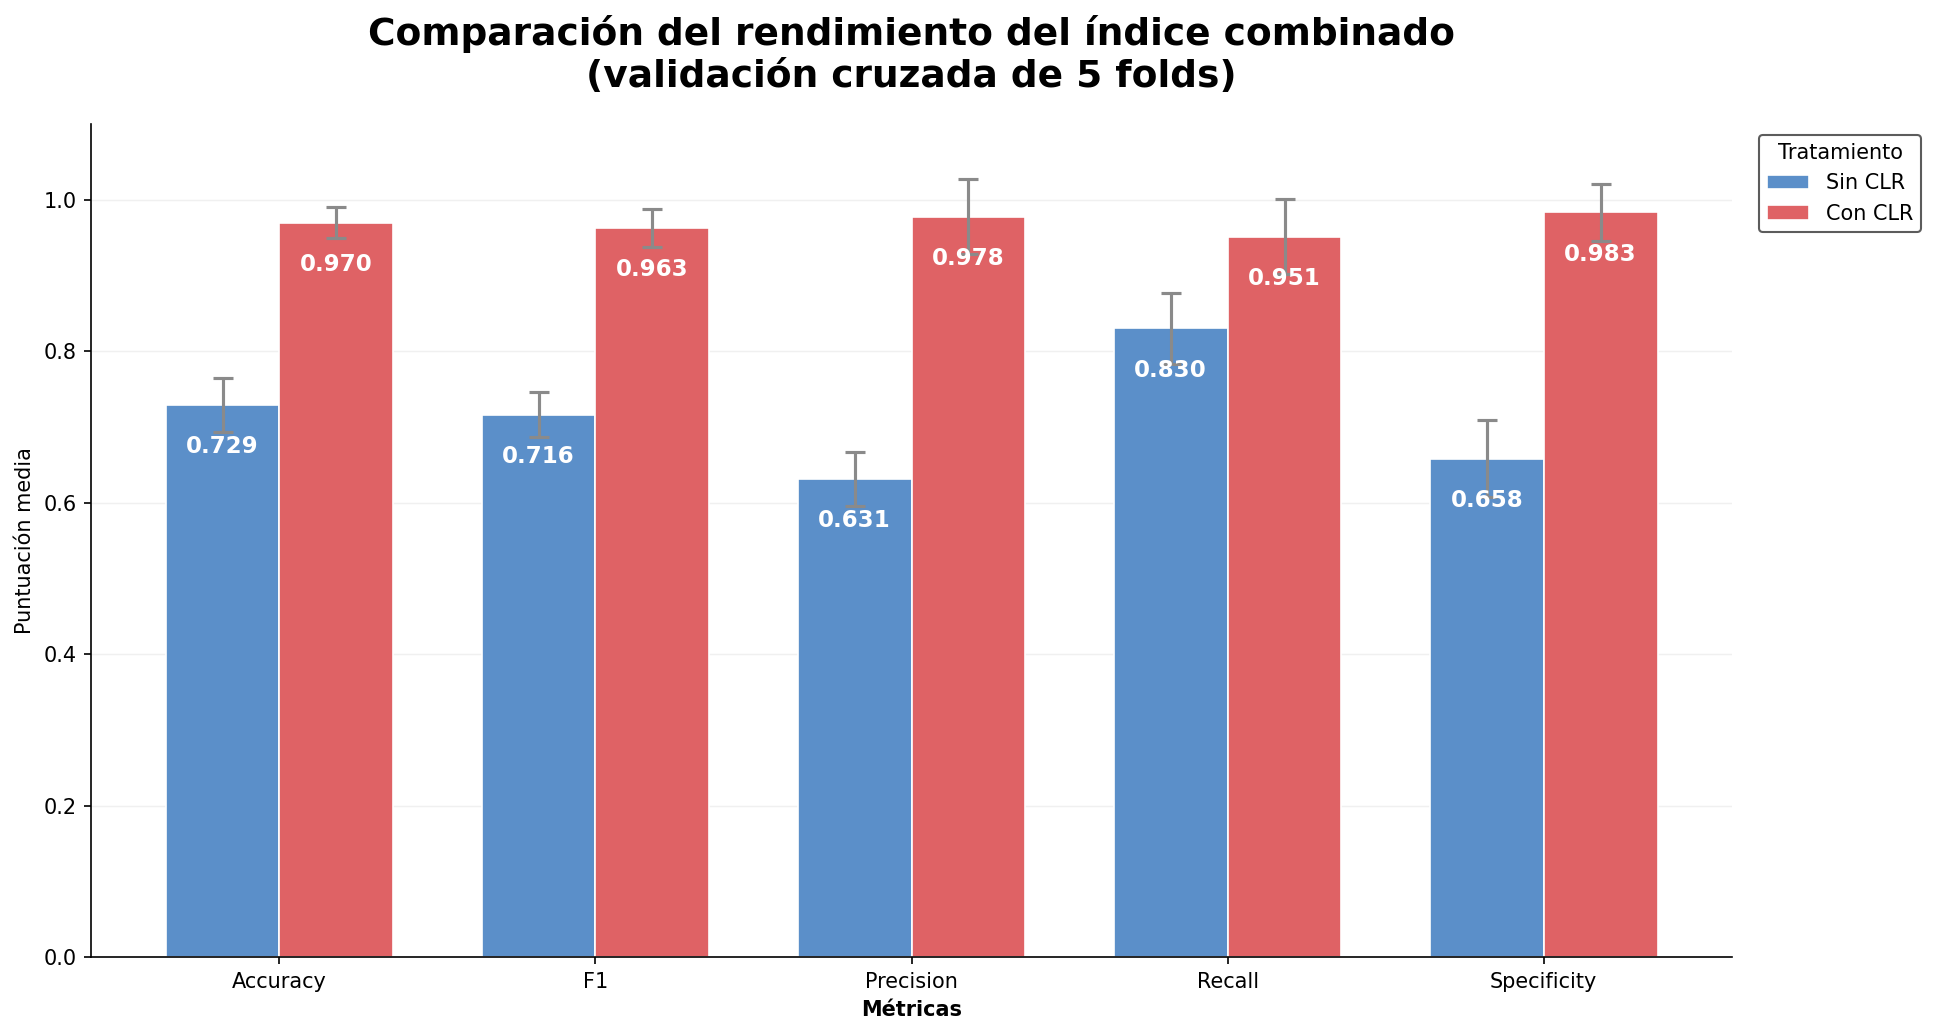

In [7]:
combined_f1 = (
    fold_metrics.loc[fold_metrics["Index"].eq("Combined")]
    .groupby("Treatment")["F1"].mean()
)

if LEGACY_POSITIONAL_ALIGNMENT:
    expected = pd.Series({
        "Without compositional treatment": 0.7061149590674622,
        "With CLR": 0.9628320683111955,
    })
    verification = pd.DataFrame({
        "Observed": combined_f1,
        "Expected original": expected,
        "Absolute difference": (combined_f1 - expected).abs(),
    })
    verification["Within tolerance"] = verification["Absolute difference"] <= 1e-6
    if not verification["Within tolerance"].all():
        print("Aviso: la implementación actual difiere ligeramente de la referencia histórica.")
else:
    verification = combined_f1.to_frame("F1 with SampleID alignment")

display(verification)


def plot_combined_performance(metrics, title, filenames):
    # Réplica visual de performance_comparison_hipca.png para el índice combinado.
    metric_order = ["Accuracy", "F1", "Precision", "Recall", "Specificity"]
    treatments = [
        ("Without compositional treatment", "Sin CLR", "#5b8fc9"),
        ("With CLR", "Con CLR", "#df6265"),
    ]
    combined = metrics.loc[metrics["Index"].eq("Combined")]
    means = combined.groupby("Treatment")[metric_order].mean()
    stds = combined.groupby("Treatment")[metric_order].std()

    x = np.arange(len(metric_order))
    width = 0.36
    fig, ax = plt.subplots(figsize=(13, 7), dpi=150)
    for position, (treatment, label, color) in enumerate(treatments):
        offset = (position - 0.5) * width
        values = means.loc[treatment, metric_order].to_numpy()
        errors = stds.loc[treatment, metric_order].to_numpy()
        bars = ax.bar(
            x + offset, values, width, label=label, color=color,
            yerr=errors, capsize=5,
            error_kw={"ecolor": "#8a8a8a", "elinewidth": 1.5, "capthick": 1.5},
            edgecolor="white", linewidth=0.8,
        )
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                max(value - 0.055, 0.025),
                f"{value:.3f}",
                ha="center", va="center", color="white",
                fontsize=11, fontweight="bold",
            )

    ax.set_xticks(x, metric_order)
    ax.set_ylabel("Puntuación media")
    ax.set_xlabel("Métricas", fontweight="bold")
    ax.set_ylim(0, 1.10)
    ax.set_title(title, fontsize=18, fontweight="bold", pad=18)
    ax.grid(axis="y", alpha=0.18, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        title="Tratamiento", frameon=True, edgecolor="#333333",
        loc="upper left", bbox_to_anchor=(1.01, 1.0),
    )
    fig.tight_layout()
    for filename in filenames:
        fig.savefig(FIGURES / filename, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


original_combined_figure = plot_combined_performance(
    fold_metrics,
    "Comparación del rendimiento del índice combinado\n(validación cruzada de 5 folds)",
    ["combined_index_performance_comparison.png", "indices_f1_comparison.png"],
)

## 8. Repetición del experimento con CAMDA 2026

### Objetivo y diseño

Se repite la comparación de los índices de Hotelling $T^2$, estadístico $Q$ e
índice combinado con los datos taxonómicos de CAMDA 2026. Las dos rutas usan
los mismos folds y se alinean explícitamente por `sample_id`:

1. **Sin tratamiento composicional:** abundancias relativas originales,
   selección KS, transformación no lineal histórica y estandarización.
2. **Con CLR:** amalgamación de especies con más de 90 % de ceros en `otros`,
   reemplazo de ceros con la mitad de la abundancia positiva mínima, CLR dentro
   de cada fold, selección KS y estandarización.

Las muestras **no occidentales** (`non_westernized = yes`) constituyen el grupo
de referencia con el que se ajustan los límites PCA. La clase positiva que se
intenta detectar es **occidental** (`non_westernized = no`). Esta dirección
reproduce la correspondencia conceptual del experimento original: ajustar la
región de referencia con el grupo rural/no occidental y detectar el grupo
urbano/occidental como desviación. Por el fuerte desbalance se reportan F1,
sensibilidad, especificidad y exactitud balanceada, además de la exactitud
convencional.

Para estudiar el efecto del balance sin depender de un único subconjunto, se
realizan **10 experimentos reproducibles**. Cada experimento conserva las 138
muestras no occidentales y selecciona aleatoriamente **200 occidentalizadas**.
El preprocesamiento composicional y los cinco folds se recalculan dentro de cada
experimento, exclusivamente con sus 338 muestras.

In [8]:
# Carga y preparación de CAMDA 2026, equivalente a 02_clr_pca_exploration.
CAMDA_DATA = EXTERNAL_DATA
CAMDA_TAXONOMY = CAMDA_DATA / "camda_2026_taxonomy_relative_abundance.tsv"
CAMDA_METADATA = CAMDA_DATA / "camda_2026_metadata.tsv"

camda_raw = pd.read_csv(CAMDA_TAXONOMY, sep="\t", index_col=0).T
camda_raw = camda_raw.apply(pd.to_numeric, errors="coerce").fillna(0.0)
camda_metadata = (
    pd.read_csv(CAMDA_METADATA, sep="\t")
    .drop_duplicates("sample_id")
    .set_index("sample_id")
)

camda_labels = camda_metadata["non_westernized"].reindex(camda_raw.index)
valid_camda = camda_labels.isin(["yes", "no"])
camda_raw = camda_raw.loc[valid_camda].copy()
camda_labels = camda_labels.loc[valid_camda].map({
    "no": "Occidental", "yes": "No occidental",
})

# Diseño de los submuestreos repetidos, aplicado sólo a CAMDA 2026.
CAMDA_WESTERNIZED_N = 200
CAMDA_EXPERIMENT_SEEDS = [7, 21, 42, 84, 101, 202, 303, 404, 505, 606]
camda_non_western_ids = camda_labels.index[camda_labels.eq("No occidental")]
camda_western_ids = camda_labels.index[camda_labels.eq("Occidental")]


def prepare_camda_composition(raw_subset):
    # Amalgamación y tratamiento de ceros idénticos a la sección CAMDA de la libreta 02.
    pseudocount = raw_subset.where(raw_subset > 0).min().min() / 2
    zero_threshold = int(0.9 * len(raw_subset))
    sparse_features = raw_subset.columns[
        (raw_subset == 0).sum(axis=0) > zero_threshold
    ]

    treated = raw_subset.copy()
    treated["otros"] = treated.loc[:, sparse_features].sum(axis=1)
    treated = treated.drop(columns=sparse_features)
    treated["otros"] += 100.0 - treated.sum(axis=1)

    zero_count_per_sample = (treated == 0).sum(axis=1)
    treated = treated.replace(0, pseudocount)
    correction = (zero_count_per_sample * pseudocount) / treated.shape[1]
    treated = treated.sub(correction, axis=0)

    tiny_negative_other = (
        (treated["otros"] < 0) & (treated["otros"] > -pseudocount)
    )
    treated.loc[tiny_negative_other, "otros"] = pseudocount
    if (treated <= 0).any().any():
        raise ValueError("CAMDA 2026: quedaron valores no positivos tras tratar los ceros.")
    return treated, pseudocount


print("Pool CAMDA:", camda_raw.shape)
print("No occidentales disponibles:", len(camda_non_western_ids))
print("Occidentalizadas disponibles:", len(camda_western_ids))
print(
    f"Diseño: {len(CAMDA_EXPERIMENT_SEEDS)} experimentos × "
    f"({len(camda_non_western_ids)} no occidentales + "
    f"{CAMDA_WESTERNIZED_N} occidentalizadas)"
)

Pool CAMDA: (3752, 1135)
No occidentales disponibles: 138
Occidentalizadas disponibles: 3614
Diseño: 10 experimentos × (138 no occidentales + 200 occidentalizadas)


### Funciones adaptadas y validación cruzada

La lógica matemática del experimento se conserva. Los nombres de las clases se
parametrizan para CAMDA 2026 y la construcción matricial se vectoriza para
evitar la fragmentación de `DataFrame` que produce la implementación histórica.
La selección de características, el escalador y el PCA se ajustan únicamente
con las muestras de entrenamiento de cada fold.

In [9]:
CAMDA_REFERENCE_LABEL = "No occidental"
CAMDA_POSITIVE_LABEL = "Occidental"


def binary_metrics_for_labels(y_true, y_pred, negative_label, positive_label):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[negative_label, positive_label]
    ).ravel()
    return {
        "F1": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Precision": precision_score(
            y_true, y_pred, pos_label=positive_label, zero_division=0
        ),
        "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Specificity": tn / (tn + fp),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    }


def make_camda_feature_matrix(feature_table, sample_ids, features, nonlinear=False):
    ordered_features = list(dict.fromkeys(features))
    available_samples = [sample for sample in sample_ids if sample in feature_table.columns]
    matrix = feature_table.reindex(
        index=ordered_features, columns=available_samples, fill_value=0.0
    ).T
    if nonlinear:
        matrix = matrix.map(custom_transform)
    return matrix


def fit_camda_index_model(feature_table, reference_ids, positive_ids,
                          compositional, p_value=KS_P_VALUE):
    reference_features, positive_features = select_features_by_ks(
        feature_table, reference_ids, positive_ids, method="exact", p_value=p_value
    )
    # Reproduce la selección original: ambos sentidos con CLR y sólo los rasgos
    # de la clase objetivo en la ruta sin tratamiento composicional.
    features = (
        reference_features + positive_features
        if compositional else positive_features
    )
    if not features:
        raise ValueError("Ninguna característica superó el umbral KS en este fold.")
    training = make_camda_feature_matrix(
        feature_table, reference_ids, features, nonlinear=not compositional
    )
    scaler = StandardScaler()
    scaled = pd.DataFrame(
        scaler.fit_transform(training), index=training.index, columns=training.columns
    )
    model = calculate_pca_parameters(scaled, PCA_VARIANCE, ALPHA)
    model.update({
        "features": list(training.columns),
        "scaler": scaler,
        "nonlinear": not compositional,
        "n_reference_features": len(reference_features),
        "n_positive_features": len(positive_features),
    })
    return model


def transform_camda_for_model(feature_table, model):
    matrix = make_camda_feature_matrix(
        feature_table, feature_table.columns, model["features"],
        nonlinear=model["nonlinear"],
    )
    return pd.DataFrame(
        model["scaler"].transform(matrix),
        index=matrix.index,
        columns=matrix.columns,
    )


def calculate_camda_indices(transformed_matrix, model):
    # Conserva la regla histórica de usar coordenadas PCA cuando las dimensiones coinciden.
    pca_coordinates = model["pca"].transform(transformed_matrix)
    index_input = (
        pca_coordinates
        if pca_coordinates.shape[1] == model["D"].shape[0]
        else transformed_matrix.to_numpy()
    )
    t2 = np.einsum("ij,jk,ik->i", index_input, model["D"], index_input)
    q = np.einsum("ij,jk,ik->i", index_input, model["C"], index_input)
    combined = np.einsum(
        "ij,jk,ik->i", index_input, model["combined_matrix"], index_input
    )
    return pd.DataFrame({
        "SampleID": transformed_matrix.index,
        "T2": t2,
        "Prediction T2": np.where(
            t2 > model["t2_threshold"], CAMDA_POSITIVE_LABEL, CAMDA_REFERENCE_LABEL
        ),
        "Q": q,
        "Prediction Q": np.where(
            q > model["q_threshold"], CAMDA_POSITIVE_LABEL, CAMDA_REFERENCE_LABEL
        ),
        "Combined Index": combined,
        "Combined Prediction": np.where(
            combined > model["combined_threshold"],
            CAMDA_POSITIVE_LABEL,
            CAMDA_REFERENCE_LABEL,
        ),
    })


def evaluate_camda_fold(treated_train, treated_test, raw_train, raw_test,
                        y_test, reference_ids, positive_ids):
    clr_train = clr_transform(treated_train)
    clr_test = clr_transform(treated_test)
    clr_model = fit_camda_index_model(
        clr_train.T, reference_ids, positive_ids, compositional=True
    )
    clr_predictions = calculate_camda_indices(
        transform_camda_for_model(clr_test.T, clr_model), clr_model
    )

    raw_model = fit_camda_index_model(
        raw_train.T, reference_ids, positive_ids, compositional=False
    )
    raw_predictions = calculate_camda_indices(
        transform_camda_for_model(raw_test.T, raw_model), raw_model
    )

    prediction_columns = {
        "T2": "Prediction T2",
        "Q": "Prediction Q",
        "Combined": "Combined Prediction",
    }
    rows = []
    for treatment, predictions, model in [
        ("Without compositional treatment", raw_predictions, raw_model),
        ("With CLR", clr_predictions, clr_model),
    ]:
        # Garantiza que las métricas sigan el orden exacto de las predicciones.
        truth = pd.Series(y_test, index=treated_test.index).loc[predictions["SampleID"]]
        for index_name, column in prediction_columns.items():
            metrics = binary_metrics_for_labels(
                truth, predictions[column], CAMDA_REFERENCE_LABEL, CAMDA_POSITIVE_LABEL
            )
            rows.append({
                "Treatment": treatment,
                "Index": index_name,
                "Selected features": len(model["features"]),
                **metrics,
            })
    return rows


def run_camda_cross_validation(treated, raw, labels):
    splitter = StratifiedKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    fold_rows = []
    for fold, (train_idx, test_idx) in enumerate(
        splitter.split(treated, labels), start=1
    ):
        train_ids = treated.index[train_idx]
        reference_ids = train_ids[labels.loc[train_ids].eq(CAMDA_REFERENCE_LABEL)]
        positive_ids = train_ids[labels.loc[train_ids].eq(CAMDA_POSITIVE_LABEL)]
        rows = evaluate_camda_fold(
            treated.iloc[train_idx], treated.iloc[test_idx],
            raw.iloc[train_idx], raw.iloc[test_idx],
            labels.iloc[test_idx].tolist(), reference_ids, positive_ids,
        )
        for row in rows:
            row["Fold"] = fold
        fold_rows.extend(rows)
    return pd.DataFrame(fold_rows)

Experimento 01/10 (semilla 7): 338 muestras, 202 rasgos para CLR


Experimento 02/10 (semilla 21): 338 muestras, 204 rasgos para CLR


Experimento 03/10 (semilla 42): 338 muestras, 202 rasgos para CLR


Experimento 04/10 (semilla 84): 338 muestras, 198 rasgos para CLR


Experimento 05/10 (semilla 101): 338 muestras, 201 rasgos para CLR


...

Experimento 07/10 (semilla 303): 338 muestras, 199 rasgos para CLR


Experimento 08/10 (semilla 404): 338 muestras, 195 rasgos para CLR


Experimento 09/10 (semilla 505): 338 muestras, 199 rasgos para CLR


Experimento 10/10 (semilla 606): 338 muestras, 197 rasgos para CLR


F1           Precision  \
                                              mean       std      mean   
Treatment                       Index                                    
With CLR                        Combined  0.925689  0.008234  0.936510   
                                Q         0.000000  0.000000  0.000000   
                                T2        0.906580  0.015866  0.944954   
Without compositional treatment Combined  0.925548  0.003855  0.870417   
                                Q         0.896547  0.017639  0.966884   
                                T2        0.931457  0.006728  0.891905   

                                                    Recall            \
                                               std    mean       std   
Treatment                       Index                                  
With CLR                        Combined  0.003041  0.9165  0.016675   
                                Q         0.000000  0.0000  0.000000   
                                T2        0.004326  0.8730  0.028304   
Without compositional treatment Combined  0.005288  0.9895  0.004378   
                                Q         0.005390  0.8390  0.029231   
                                T2        0.004929  0.9760  0.011005   

                                         Specificity            Accuracy  \
                                                mean       std      mean   
Treatment                       Index                                      
With CLR                        Combined    0.909550  0.005135  0.913573   
                                Q           1.000000  0.000000  0.408253   
                                T2          0.926058  0.006558  0.894636   
Without compositional treatment Combined    0.783519  0.009657  0.905176   
                                Q           0.956429  0.007530  0.886910   
                                T2          0.826111  0.007980  0.914618   

                                                   Balanced Accuracy  \
                                               std              mean   
Treatment                       Index                                  
With CLR                        Combined  0.008781          0.913025   
                                Q         0.000000          0.500000   
                                T2        0.015948          0.899529   
Without compositional treatment Combined  0.004921          0.886509   
                                Q         0.017176          0.897714   
                                T2        0.007967          0.901056   

                                                   Selected features            
                                               std              mean       std  
Treatment                       Index                                           
With CLR                        Combined  0.007143            186.24  2.740316  
                                Q         0.000000            186.24  2.740316  
                                T2        0.013420            186.24  2.740316  
Without compositional treatment Combined  0.005483             82.36  3.755648  
                                Q         0.014523             82.36  3.755648  
                                T2        0.007562             82.36  3.755648

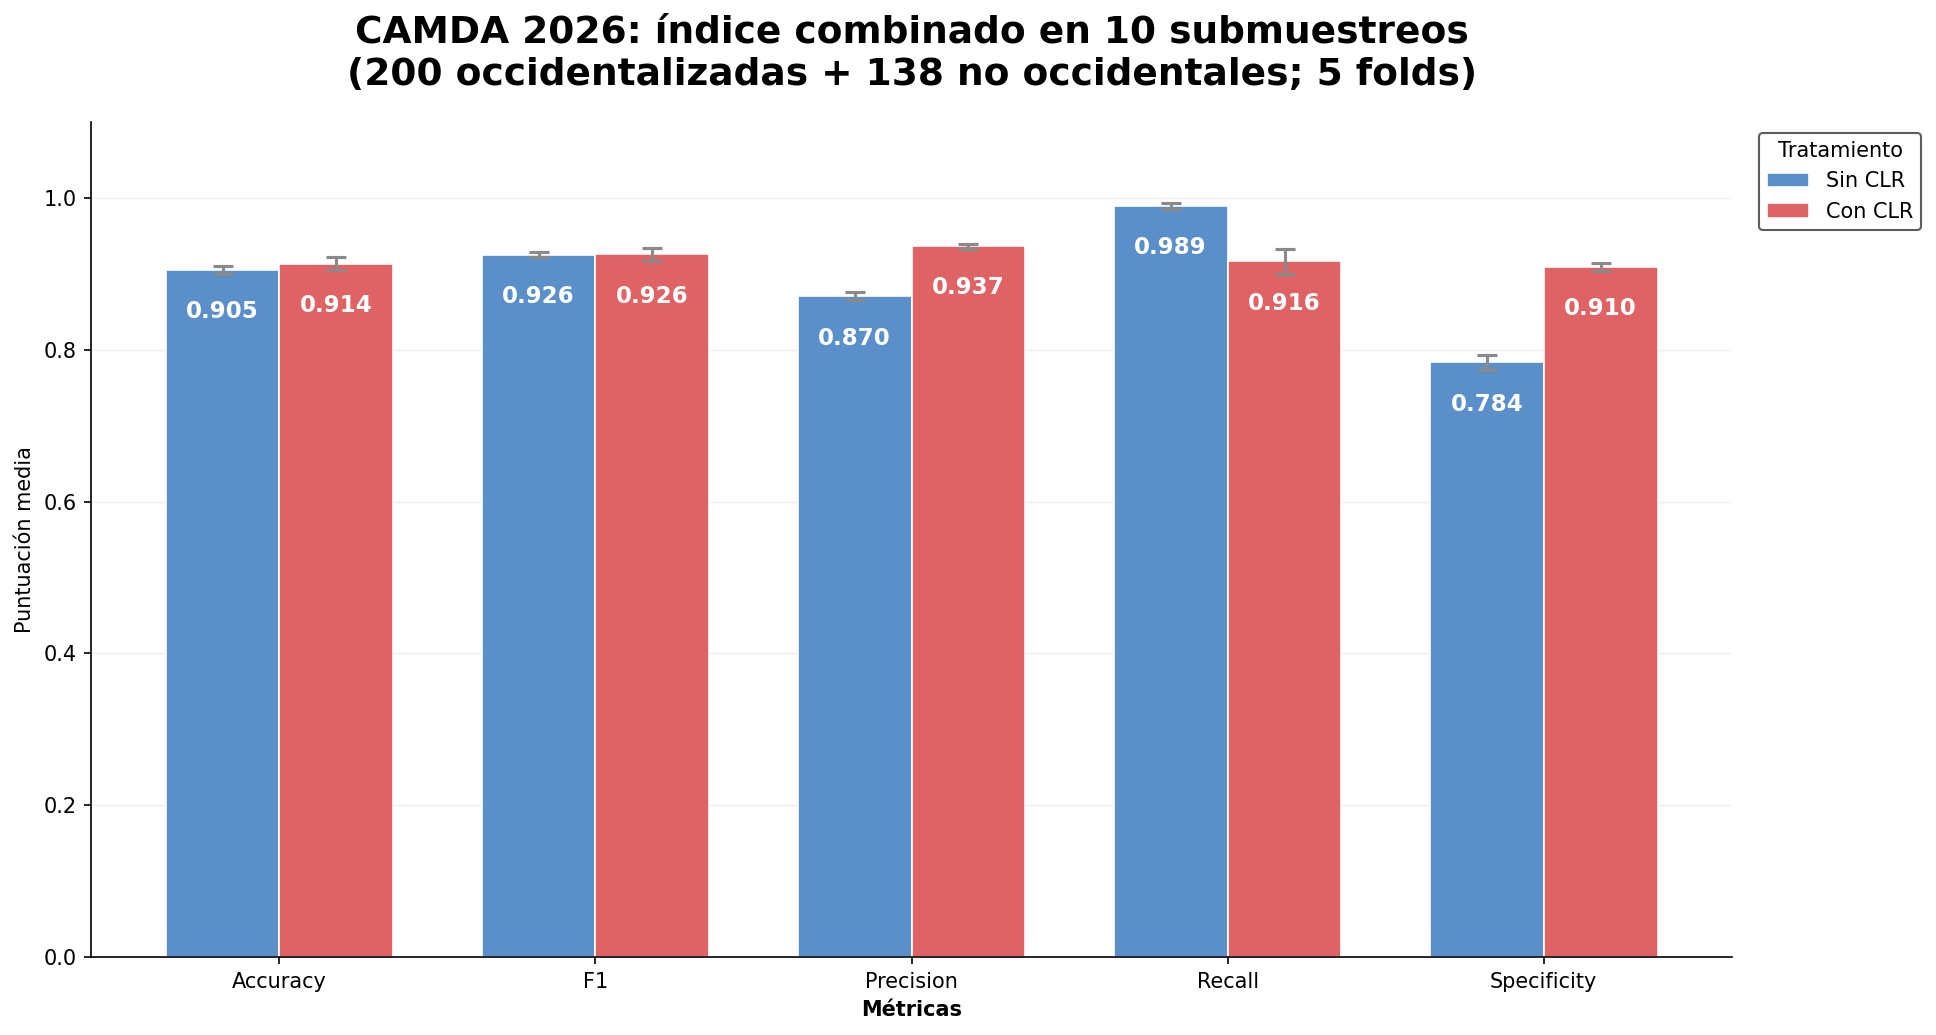

In [10]:
camda_experiment_rows = []
for experiment, seed in enumerate(CAMDA_EXPERIMENT_SEEDS, start=1):
    sampled_western_ids = (
        camda_labels.loc[camda_western_ids]
        .sample(n=CAMDA_WESTERNIZED_N, random_state=seed)
        .index
    )
    selected_ids = camda_labels.index[
        camda_labels.index.isin(camda_non_western_ids.union(sampled_western_ids))
    ]
    raw_subset = camda_raw.loc[selected_ids].copy()
    labels_subset = camda_labels.loc[selected_ids].copy()
    treated_subset, pseudocount = prepare_camda_composition(raw_subset)

    experiment_folds = run_camda_cross_validation(
        treated_subset, raw_subset, labels_subset
    )
    experiment_folds["Experiment"] = experiment
    experiment_folds["Seed"] = seed
    experiment_folds["Samples"] = len(selected_ids)
    experiment_folds["CLR input features"] = treated_subset.shape[1]
    experiment_folds["Pseudocount"] = pseudocount
    camda_experiment_rows.append(experiment_folds)
    print(
        f"Experimento {experiment:02d}/{len(CAMDA_EXPERIMENT_SEEDS)} "
        f"(semilla {seed}): {len(selected_ids)} muestras, "
        f"{treated_subset.shape[1]} rasgos para CLR"
    )

camda_fold_metrics = pd.concat(camda_experiment_rows, ignore_index=True)
camda_metric_columns = [
    "F1", "Precision", "Recall", "Specificity", "Accuracy",
    "Balanced Accuracy", "Selected features",
]
camda_experiment_metrics = (
    camda_fold_metrics.groupby(["Experiment", "Seed", "Treatment", "Index"])
    [camda_metric_columns].mean().reset_index()
)
camda_summary = (
    camda_experiment_metrics.groupby(["Treatment", "Index"])
    [[
        "F1", "Precision", "Recall", "Specificity", "Accuracy",
        "Balanced Accuracy", "Selected features",
    ]]
    .agg(["mean", "std"])
)

camda_fold_metrics.to_csv(OUTPUT / "camda_2026_fold_metrics.csv", index=False)
camda_experiment_metrics.to_csv(
    OUTPUT / "camda_2026_experiment_metrics.csv", index=False
)
camda_summary.to_csv(OUTPUT / "camda_2026_metrics_summary.csv")
display(camda_summary)

camda_combined_figure = plot_combined_performance(
    camda_experiment_metrics,
    "CAMDA 2026: índice combinado en 10 submuestreos\n(200 occidentalizadas + 138 no occidentales; 5 folds)",
    [
        "camda_2026_combined_index_performance_comparison.png",
        "camda_2026_indices_f1_comparison.png",
    ],
)

### Resultados e interpretación

Se ejecutaron **10 experimentos**; cada uno incluyó las 138 muestras no
occidentales y una selección aleatoria de 200 occidentalizadas. Los valores
siguientes son la media y desviación estándar entre los resultados medios de
los diez experimentos y consideran únicamente el **índice combinado**.

Con CLR se obtuvo **F1 = 0.926 ± 0.008**, exactitud **0.914 ± 0.009**,
precisión **0.937 ± 0.003**, sensibilidad **0.917 ± 0.017**, especificidad
**0.910 ± 0.005** y exactitud balanceada **0.913 ± 0.007**. Sin CLR se obtuvo
**F1 = 0.926 ± 0.004**, exactitud **0.905 ± 0.005**, precisión
**0.870 ± 0.005**, sensibilidad **0.990 ± 0.004**, especificidad
**0.784 ± 0.010** y exactitud balanceada **0.887 ± 0.005**.

CLR superó a la ruta sin CLR en **exactitud balanceada, precisión y
especificidad en los 10 de 10 experimentos**, en exactitud en 8 de 10 y en F1
en 6 de 10. La ventaja media de CLR fue **+0.0265 en exactitud balanceada**,
mientras que el F1 promedio fue prácticamente idéntico entre tratamientos.
Sin CLR mantuvo mayor sensibilidad en los 10 experimentos. En consecuencia,
los submuestreos más balanceados sí aportan evidencia consistente de que CLR
mejora la separación equilibrada entre ambos grupos, aunque intercambia parte
de la sensibilidad por mucha mayor especificidad.